#  Entropy aggregation calibration 
### (Learning weight in aggregating attn and final token entropy)

In [40]:
import sys

import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import torch
import torch.nn as nn
from tqdm import tqdm
from typing import Optional

sys.path.append("../../../services/")
from index import Index, IndexDataset
from process_funcs import retrieve_answer_token_index
from metric_funcs import (
    calculate_ece_adaptive_bins, 
    calculate_norm_entropy, 
    calculate_roc_auc
)

## Environment preparation

In [41]:
LAYERS_COUNT = 28
HEADS_COUNT = 28 
HPARAMETER_SEARCH_TRIALS = 20
BEST_HEADS_GROUP_SIZE = 7

torch.random.manual_seed(42)

In [42]:
for i in range(torch.cuda.device_count()):
    props = torch.cuda.get_device_properties(i)
    print(f"Index {i}: {props.name}, UUID: {props.uuid}")

Index 0: NVIDIA L40, UUID: 441e6008-cd27-34b5-c81a-17dad9d4a894
Index 1: NVIDIA L40S, UUID: c15d4e7a-29b2-896a-f7bf-3d1a528040a5
Index 2: NVIDIA L40, UUID: 31a471eb-a3b0-032b-8b74-9bd805c42af3
Index 3: NVIDIA L40, UUID: 7b7e27a5-a434-d736-eabd-b9414645af76
Index 4: NVIDIA L40S, UUID: d5913034-d8e8-b46e-940e-7df6d85d3884
Index 5: NVIDIA H100 NVL, UUID: d4d3fa02-fdea-80f5-9082-0157b1423027
Index 6: NVIDIA H100 PCIe, UUID: 1ea36751-5cc4-4522-aa5e-55350c485c0c


In [43]:
device = torch.device("cuda:3" if torch.cuda.is_available() else "cpu")
print(device)

cuda:3


## Core functions

In [44]:
# Funtion that calculates confidence of LLM's answers 
# based on aggregation of attention and final answer token distributions entropies

def calculate_llm_confidence(attn_confidence: torch.Tensor, final_token_confidence: torch.Tensor, gamma=0.7):
    aggregated_confidence = gamma * attn_confidence + (1 - gamma) * final_token_confidence
    return aggregated_confidence

In [45]:
# Module which will learn parameters for llm beta calibration

class BetaCalibration(nn.Module):
    def __init__(self, device=device):
        super().__init__()
        self.log_a = nn.Parameter(torch.tensor(0.0, device=device))
        self.log_b = nn.Parameter(torch.tensor(0.0, device=device))
        self.c = nn.Parameter(torch.tensor(0.0, device=device))
        self.logit_gamma = nn.Parameter(torch.tensor(0.0, device=device))
        self.eps = 1e-8

    def forward(self, attention_confidence, final_answer_confidence):
        gamma = torch.sigmoid(self.logit_gamma)
        aggregated_confidence = calculate_llm_confidence(
            attention_confidence,
            final_answer_confidence,
            gamma
        )

        a = torch.exp(self.log_a)
        b = torch.exp(self.log_b)
        calibrated_confidence = torch.sigmoid(
            self.c + a * torch.log(aggregated_confidence) - b * torch.log(1 - aggregated_confidence)
        )
        return calibrated_confidence
    
    def calibrate(self, attention_confidence, final_answer_confidence):
        self.eval()
        with torch.no_grad():
            return self.forward(attention_confidence, final_answer_confidence).cpu()

In [46]:
# Function to find indices of best layer and head based on TOHA article

def find_best_layer_head_hal_dif_power(train_data):
    hallu_elem_ids = torch.argwhere(train_data["labels"] == False)
    truth_elem_ids = torch.argwhere(train_data["labels"] == True)

    hal_dif_power_results = torch.stack(
        [
            train_data[f"attn_entropy{l}_{h}"][hallu_elem_ids].mean() - train_data[f"attn_entropy{l}_{h}"][truth_elem_ids].mean()
            for l in range(LAYERS_COUNT)
                for h in range(HEADS_COUNT)
        ]
    )
    
    hal_dif_power_matrix = hal_dif_power_results.reshape(LAYERS_COUNT, HEADS_COUNT).cpu()

    plt.figure(figsize=(5, 4))

    sns.heatmap(hal_dif_power_matrix, annot=False, cmap="Reds")
    plt.title("Hallucination difference power values by Layer and Head")
    plt.xlabel("Head ID")
    plt.ylabel("Layer ID")
    plt.gca().invert_yaxis()
    plt.show()
    
    best_score_idx = torch.argsort(hal_dif_power_results, descending=True)[:BEST_HEADS_GROUP_SIZE]
    print(f"Best metric value: {torch.max(hal_dif_power_results).item()}")
    
    return best_score_idx // LAYERS_COUNT, best_score_idx % HEADS_COUNT

In [47]:
# Function to find indices of best layer and head based on ROC AUC

def find_best_layer_head_roc_auc(train_data):
    roc_auc_results = torch.stack(
        [
            torch.tensor(calculate_roc_auc(
                train_data[f"attn_entropy{l}_{h}"], 
                1 - train_data[f"labels"]
            ))
            for l in range(LAYERS_COUNT)
                for h in range(HEADS_COUNT)
        ]
    )

    roc_auc_matrix = roc_auc_results.reshape(LAYERS_COUNT, HEADS_COUNT).cpu()

    plt.figure(figsize=(5, 4))

    sns.heatmap(roc_auc_matrix, annot=False, cmap="Reds")
    plt.title("ROC AUC values by Layer and Head")
    plt.xlabel("Head ID")
    plt.ylabel("Layer ID")
    plt.gca().invert_yaxis()
    plt.show()
    
    best_score_idx = torch.argsort(roc_auc_results, descending=True)[:BEST_HEADS_GROUP_SIZE]
    print(f"Best metric value: {torch.max(roc_auc_results).item()}")
    
    return best_score_idx // LAYERS_COUNT, best_score_idx % HEADS_COUNT

In [48]:
# Function to fit the calibration model

def fit_calibration_model(
    model: nn.Module,
    train_data: IndexDataset,
    test_data: Optional[IndexDataset] = None,
    lr_max=1e-2,
    lr_min=1e-4,
    batch_size=64,
    epochs=3,
    plot_interval=3,
    verbose=True
):
    optimizer = torch.optim.Adam(model.parameters(), lr_max)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
        optimizer, epochs * (len(train_data) / batch_size), lr_min
    )

    train_losses = []
    test_losses = []
    iterations = []

    iteration_counter = 0

    for _ in range(epochs):
        for start in range(0, len(train_data) - batch_size, batch_size):
            train_batch = train_data.get(start, start + batch_size)
            if not train_batch:
                continue

            optimizer.zero_grad()

            train_batch_norm_attn_entropy = train_batch["attn_confidence"].to(device=device, dtype=torch.float32)
            train_batch_final_scores = train_batch["final_token_confidence"].to(device=device, dtype=torch.float32)
            train_cal_confidence = model(train_batch_norm_attn_entropy, train_batch_final_scores)
            
            train_batch_labels = train_batch["labels"].to(device=device, dtype=torch.float32)
            
            train_loss = torch.nn.functional.binary_cross_entropy(
                train_cal_confidence,
                train_batch_labels
            )

            train_loss.backward()
            # torch.nn.utils.clip_grad_norm_(temp_model.parameters(), max_norm=1.0)
            optimizer.step()
            scheduler.step()

            if (
                test_data is not None
                and iteration_counter % plot_interval == 0
            ):
                train_loss = train_loss.item()
                train_losses.append(train_loss)

                test_batch = test_data.get(0, min(batch_size, len(test_data)))
                if test_batch:
                    test_batch_attn_confidence = test_batch["attn_confidence"].to(device=device, dtype=torch.float32)
                    test_batch_final_token_confidence = test_batch["final_token_confidence"].to(device=device, dtype=torch.float32)
                    
                    test_batch_labels = test_batch["labels"].to(device=device, dtype=torch.float32)
                    
                    with torch.no_grad():
                        test_cal_confidence = model(test_batch_attn_confidence, test_batch_final_token_confidence)
                        test_loss = torch.nn.functional.binary_cross_entropy(
                            test_cal_confidence,
                            test_batch_labels
                        )
                        test_losses.append(test_loss.item())
                    
                    iterations.append(iteration_counter)
            iteration_counter += 1


    if len(iterations) > 0 and verbose:
        plt.figure(figsize=(4, 4))
        plt.plot(iterations, train_losses, label="Train Loss", marker="o")
        if len(test_losses) > 0:
            plt.plot(iterations, test_losses, label="Test Loss", marker="s")
        plt.xlabel("Iteration")
        plt.ylabel("Loss")
        plt.title("Training and Test Loss over Iterations")
        plt.legend()
        plt.grid(True, alpha=0.3)
        plt.show()

    return model

In [49]:
# Function to find the best hyperparameters for calibration model

def fit_hparameters(
    train: IndexDataset,
    test: IndexDataset,
    verbose=False
    ):
    results = []
    for _ in tqdm(range(HPARAMETER_SEARCH_TRIALS)):
        lr_max = np.random.choice([1e-2, 5e-3, 1e-3, 5e-4, 1e-4])
        lr_min = np.random.choice([1e-3, 1e-4, 5e-5, 1e-5, 5e-6, 1e-6])
        batch_size = 16
        epochs = np.random.choice([3, 5, 10])

        model = fit_calibration_model(
            BetaCalibration(),
            train_data=train,
            test_data=test,
            lr_max=lr_max,
            lr_min=lr_min,
            batch_size=batch_size,
            epochs=epochs,
            verbose=verbose
        )
        
        test_data = test.get()
        val_calibrated_probs = model.calibrate(test_data["attn_confidence"], test_data["final_token_confidence"])    
        ece = calculate_ece_adaptive_bins(
            val_calibrated_probs,
            test.get()["labels"],
            verbose=verbose,
            device=device 
        )
        
        print(f"Current ECE: {ece}")
        results.append(
            {
                "hparameters": {
                    "lr_max": lr_max,
                    "lr_min": lr_min,
                    "batch_size": batch_size,
                    "epochs": epochs,
                },
                "parameters": model.state_dict(),
                "ece": ece,
            }
        )

    return min(results, key=lambda x: x["ece"])

In [50]:
# Function to test calibration model

def test_calibration_model(
    model: nn.Module,
    X1_test: torch.Tensor,
    X2_test: torch.Tensor,
    y_test: torch.Tensor
):
    not_calibrated_test_answers_probs = calculate_llm_confidence(X1_test, X2_test)
    calibrated_test_answers_probs = model.calibrate(
        X1_test, X2_test
    )
    
    print(
        f"ECE on NON calibrated answer (test data): {
            calculate_ece_adaptive_bins(
            not_calibrated_test_answers_probs,
            y_test,
            verbose=True,
            device=device
            )
        }"
    )

    print(
        f"ECE on calibrated answer (test data): {
            calculate_ece_adaptive_bins(
            calibrated_test_answers_probs,
            y_test,
            verbose=True,
            device=device
            )
        }"
    )
    
    accuracies = (
        y_test
    ).to(torch.float)
    print(f"Accuracy on answer from test: {torch.mean(accuracies).item()}")

## Index preparation 

In [51]:
index = Index("../../../index_data/qwen2.5_MMLU-PRO_attn_cropped_12000")

In [52]:
# Function to process data for training phase

def create_process_elements_main(best_layers, best_heads):
    def process_elements_main(index_data: np.array):
        processed = {}

        # Getting labels of if the answer is correct or not 
        labels = torch.zeros(len(index_data), device=device, dtype=torch.long)
        for i, elem in enumerate(index_data):
            answer_token_index = retrieve_answer_token_index(elem["score_data"])
            labels[i] = (elem["score_data"][answer_token_index]["token"] == str(ord(elem["dataset_elem"]["answer"]) - ord('A')))
        processed["labels"] = labels
                
        # Getting normilized attn entropy scores for the answer token distribution 
        # for each best layer and head pair 
        agg_norm_attn_entropy = torch.stack([
                torch.stack([
                    x["norm_attention_entropy"][0][l][h] 
                    for l, h in zip(best_layers, best_heads)
                ])
                for x in index_data
            ]).squeeze(-1).mean(-1).to(dtype=torch.float32, device=device)
            
        # Getting probability scores of the answer token 
        # from the last layer of the LLM
        final_token_scores = torch.stack(
            [
                x
                ["score_data"]
                [retrieve_answer_token_index(x["score_data"])]
                ["top_probs"] 
                for x in index_data
            ]
        ).clamp(1e-8).to(dtype=torch.float32, device=device)
        
        processed["attn_confidence"] = 1 - agg_norm_attn_entropy    
        processed["final_token_confidence"] = 1 - calculate_norm_entropy(final_token_scores)
            
        return processed
    return process_elements_main

In [53]:
# Function to process data for head selection phase

def process_elements_hal(index_data: np.array):
    processed = {}
    
    # Getting labels of if the answer is correct or not 
    labels = torch.zeros(len(index_data), device=device, dtype=torch.long)
    for i, elem in enumerate(index_data):
        answer_token_index = retrieve_answer_token_index(elem["score_data"])
        labels[i] = (elem["score_data"][answer_token_index]["token"] == str(ord(elem["dataset_elem"]["answer"]) - ord('A')))
    processed["labels"] = labels

    for l in tqdm(range(LAYERS_COUNT)):
        for h in range(HEADS_COUNT):
            processed[f"attn_entropy{l}_{h}"] = torch.stack(
                [x["attention_entropy"][0][l][h] for x in index_data]
            ).squeeze(-1).to(dtype=torch.float32, device=device)
            
            processed[f"norm_attn_entropy{l}_{h}"] = torch.stack(
                [x["norm_attention_entropy"][0][l][h] for x in index_data]
            ).squeeze(-1).to(dtype=torch.float32, device=device)
        
    return processed

## Head selection

In [54]:
head_selection_dataset = IndexDataset(
    index, process_elements_hal, split="val", load_all_data=True
)

100%|██████████| 28/28 [00:05<00:00,  5.40it/s]


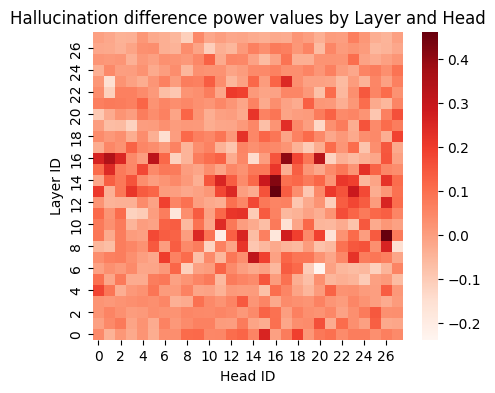

Best metric value: 0.4627213478088379
Best Layers and Heads: [(9, 26), (13, 16), (14, 16), (16, 17), (16, 1), (16, 20), (16, 5)]


In [55]:
hal_dif_best_layers, hal_dif_best_heads = find_best_layer_head_hal_dif_power(head_selection_dataset.get())
print(f"Best Layers and Heads: {[(x[0].item(), x[1].item()) for x  in zip(hal_dif_best_layers, hal_dif_best_heads)]}")

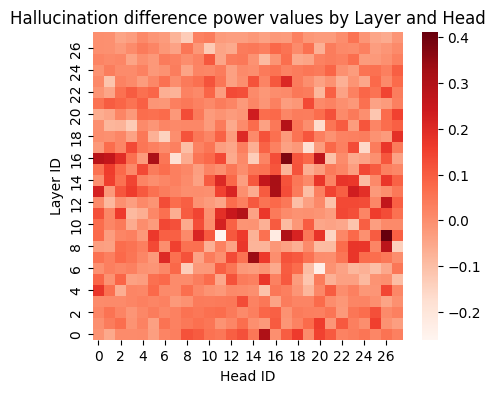

Best metric value: 0.41211438179016113
Best Layers and Heads: [(9, 26), (16, 17), (7, 14), (14, 16), (13, 16), (16, 5), (0, 15)]


In [56]:
hal_dif_best_layers, hal_dif_best_heads = find_best_layer_head_hal_dif_power(head_selection_dataset.get(end=500))
print(f"Best Layers and Heads: {[(x[0].item(), x[1].item()) for x  in zip(hal_dif_best_layers, hal_dif_best_heads)]}")

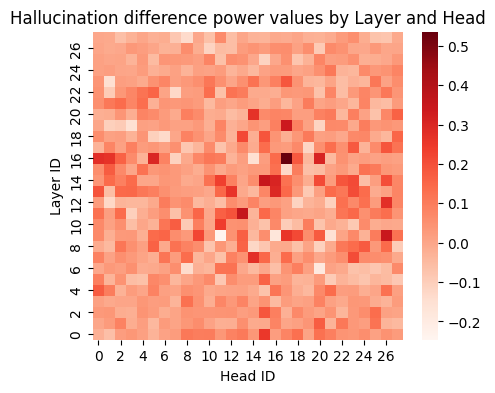

Best metric value: 0.5355830192565918
Best Layers and Heads: [(16, 17), (11, 13), (14, 15), (9, 26), (19, 17), (16, 20), (14, 16)]


In [57]:
hal_dif_best_layers, hal_dif_best_heads = find_best_layer_head_hal_dif_power(head_selection_dataset.get(end=200))
print(f"Best Layers and Heads: {[(x[0].item(), x[1].item()) for x  in zip(hal_dif_best_layers, hal_dif_best_heads)]}")

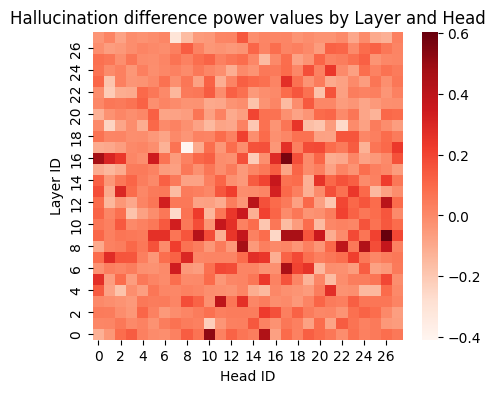

Best metric value: 0.6042666435241699
Best Layers and Heads: [(9, 26), (16, 17), (0, 10), (16, 0), (8, 13), (9, 18), (6, 17)]


In [58]:
hal_dif_best_layers, hal_dif_best_heads = find_best_layer_head_hal_dif_power(head_selection_dataset.get(end=50))
print(f"Best Layers and Heads: {[(x[0].item(), x[1].item()) for x  in zip(hal_dif_best_layers, hal_dif_best_heads)]}")

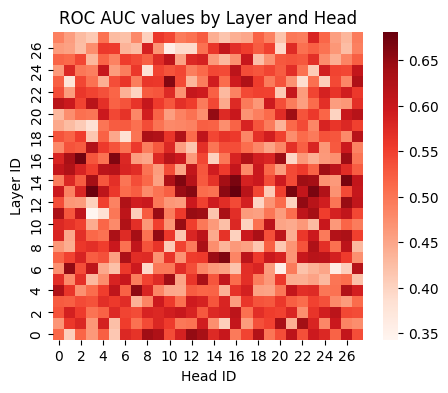

Best metric value: 0.681026816368103
Best Layers and Heads: [(13, 16), (13, 3), (16, 2), (14, 26), (13, 21), (14, 16), (13, 23)]


In [59]:
roc_auc_best_layers, roc_auc_best_heads = find_best_layer_head_roc_auc(head_selection_dataset.get())
print(f"Best Layers and Heads: {[(x[0].item(), x[1].item()) for x  in zip(roc_auc_best_layers, roc_auc_best_heads)]}")

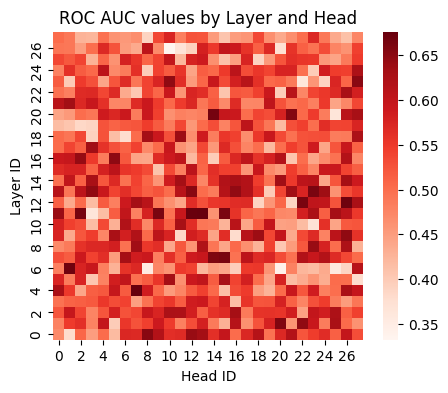

Best metric value: 0.6764373183250427
Best Layers and Heads: [(4, 7), (11, 13), (11, 12), (6, 1), (12, 26), (20, 14), (11, 2)]


In [65]:
roc_auc_best_layers, roc_auc_best_heads = find_best_layer_head_roc_auc(head_selection_dataset.get(end=500))
print(f"Best Layers and Heads: {[(x[0].item(), x[1].item()) for x  in zip(roc_auc_best_layers, roc_auc_best_heads)]}")

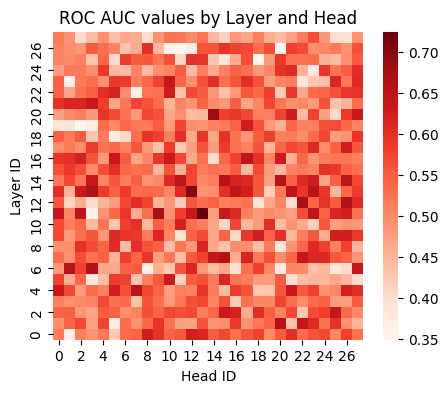

Best metric value: 0.7245593070983887
Best Layers and Heads: [(11, 13), (13, 12), (20, 14), (11, 9), (12, 22), (13, 3), (12, 26)]


In [64]:
roc_auc_best_layers, roc_auc_best_heads = find_best_layer_head_roc_auc(head_selection_dataset.get(end=200))
print(f"Best Layers and Heads: {[(x[0].item(), x[1].item()) for x  in zip(roc_auc_best_layers, roc_auc_best_heads)]}")

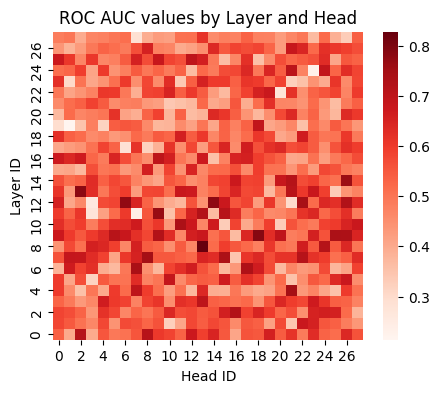

Best metric value: 0.8274428248405457
Best Layers and Heads: [(8, 13), (9, 18), (13, 2), (12, 14), (12, 6), (11, 9), (14, 26)]


In [63]:
roc_auc_best_layers, roc_auc_best_heads = find_best_layer_head_roc_auc(head_selection_dataset.get(end=50))
print(f"Best Layers and Heads: {[(x[0].item(), x[1].item()) for x  in zip(roc_auc_best_layers, roc_auc_best_heads)]}")

## Calibration based on entropy aggregation: 
* TOHA based attn head selection
* Confidence - aggregated entropy from best head and final layer scores
* Calibration layer - Beta calibration 

### Data preparing 

In [60]:
train = IndexDataset(
    index, create_process_elements_main(hal_dif_best_layers, hal_dif_best_heads), split="train", load_all_data=True
)
val = IndexDataset(
    index, create_process_elements_main(hal_dif_best_layers, hal_dif_best_heads), split="val", load_all_data=True
)
test = IndexDataset(
    index, create_process_elements_main(hal_dif_best_layers, hal_dif_best_heads), split="test", load_all_data=True
)

### Training model and finding best hparameters

  0%|          | 0/20 [00:00<?, ?it/s]

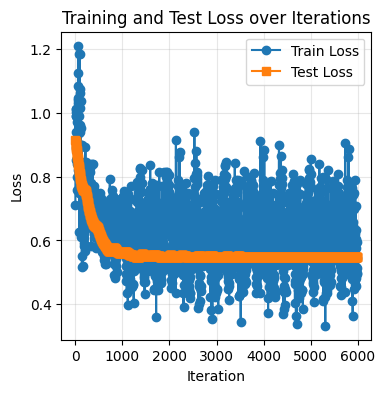

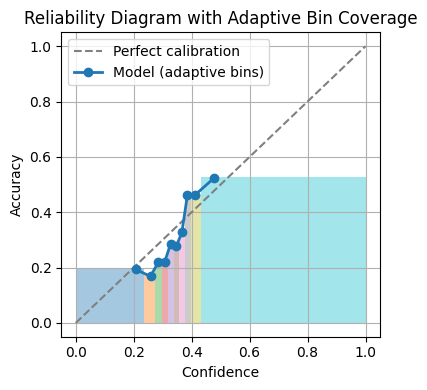

  5%|▌         | 1/20 [00:09<02:52,  9.05s/it]

Current ECE: 0.057976141571998596


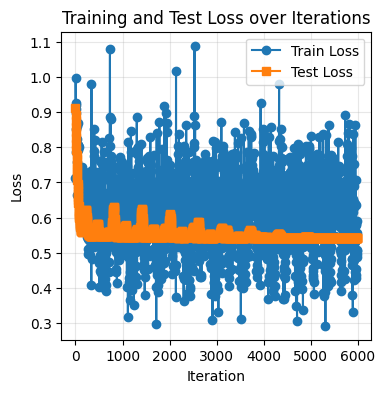

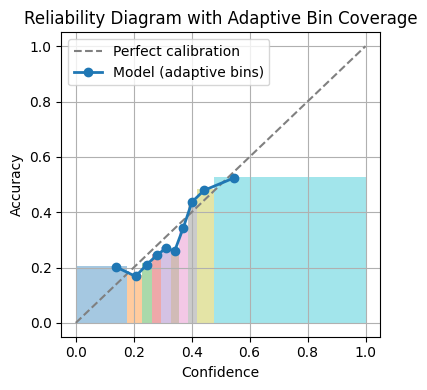

 10%|█         | 2/20 [00:18<02:50,  9.48s/it]

Current ECE: 0.04111044481396675


 10%|█         | 2/20 [00:19<02:59,  9.97s/it]


KeyboardInterrupt: 

In [61]:
fit_results = fit_hparameters(
    train=train,
    test=val,
    verbose=True
)

### Testing model

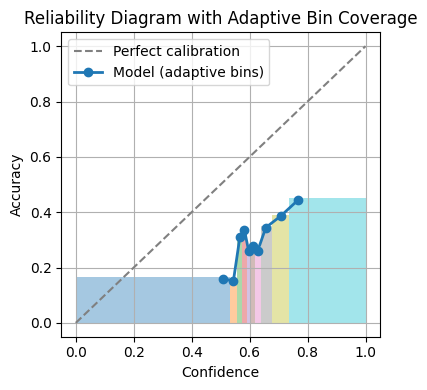

ECE on NON calibrated answer (test data): 0.3235242962837219


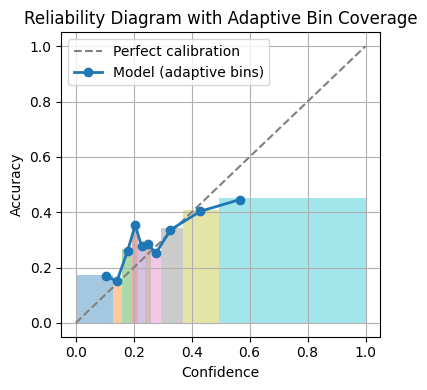

ECE on calibrated answer (test data): 0.05751724913716316
Accuracy on answer from test: 0.2944120168685913


In [ ]:
model = BetaCalibration()
model.load_state_dict(fit_results["parameters"])
model.eval()
    
test_data = test.get()
    
test_calibration_model(
    model,
    test_data["attn_confidence"], test_data["final_token_confidence"],
    test_data["labels"],
)

In [ ]:
[x for x in model.named_parameters()]

[('log_a',
  Parameter containing:
  tensor(1.3911, device='cuda:3', requires_grad=True)),
 ('log_b',
  Parameter containing:
  tensor(0.0516, device='cuda:3', requires_grad=True)),
 ('c',
  Parameter containing:
  tensor(-0.4219, device='cuda:3', requires_grad=True)),
 ('logit_gamma',
  Parameter containing:
  tensor(0.5690, device='cuda:3', requires_grad=True))]

## Calibration based on entropy aggregation: 
* ROC AUC based attn head selection
* Confidence - aggregated entropy from best head and final layer scores
* Calibration layer - Beta calibration 

### Data preparing 

In [ ]:
train = IndexDataset(
    index, create_process_elements_main(roc_auc_best_layers, roc_auc_best_heads), split="train", load_all_data=True
)
val = IndexDataset(
    index, create_process_elements_main(roc_auc_best_layers, roc_auc_best_heads), split="val", load_all_data=True
)
test = IndexDataset(
    index, create_process_elements_main(roc_auc_best_layers, roc_auc_best_heads), split="test", load_all_data=True
)

### Finding best layer and head

### Training model and finding best hparameters

  0%|          | 0/20 [00:00<?, ?it/s]

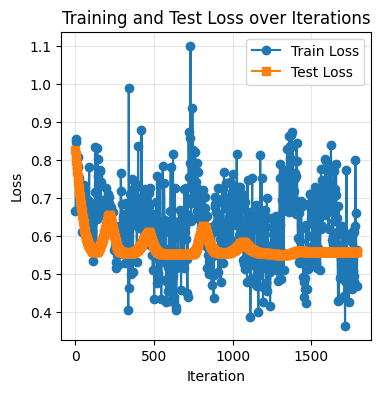

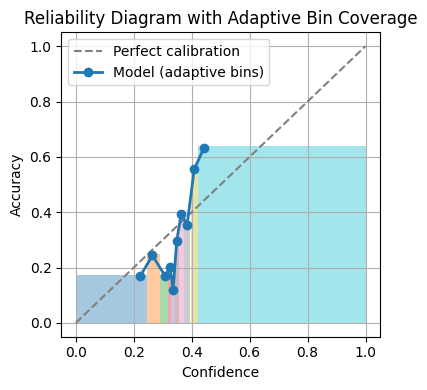

  5%|▌         | 1/20 [00:02<00:55,  2.91s/it]

Current ECE: 0.1017034500837326


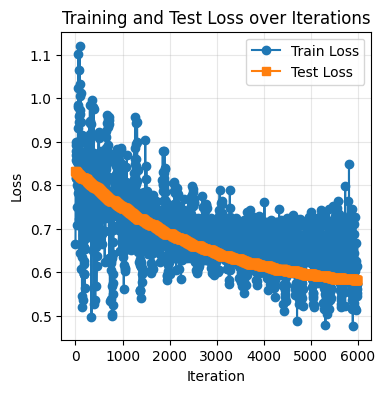

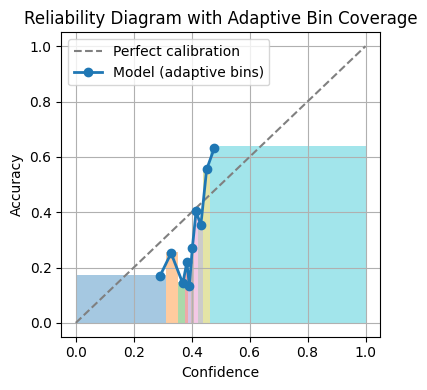

 10%|█         | 2/20 [00:13<02:09,  7.21s/it]

Current ECE: 0.13306260108947754


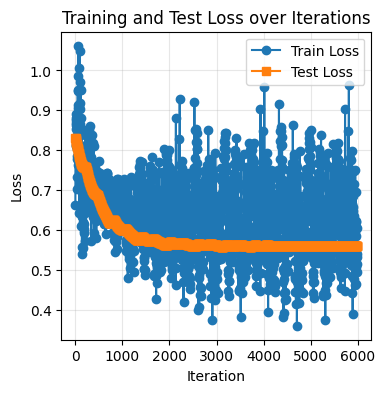

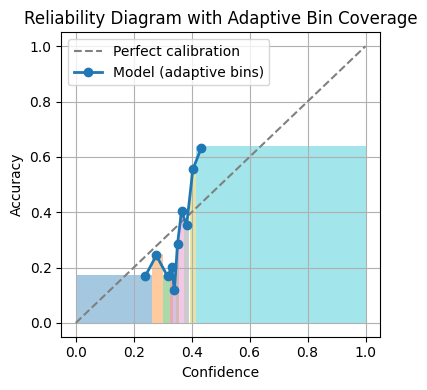

 15%|█▌        | 3/20 [00:23<02:25,  8.53s/it]

Current ECE: 0.10970674455165863


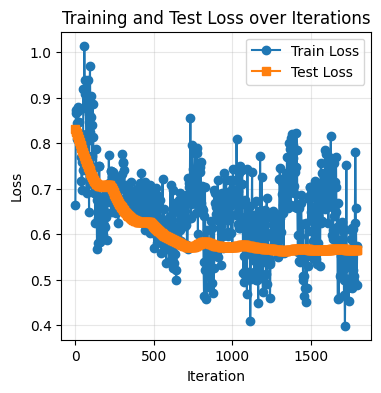

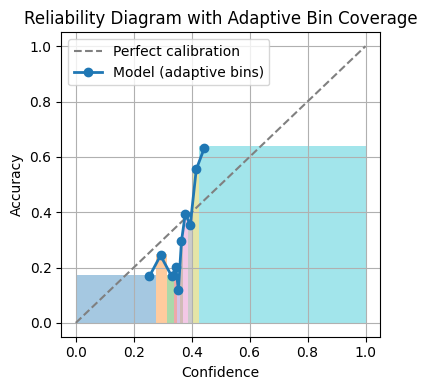

 20%|██        | 4/20 [00:26<01:41,  6.35s/it]

Current ECE: 0.11412099003791809


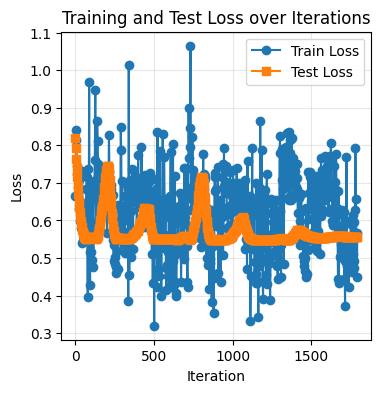

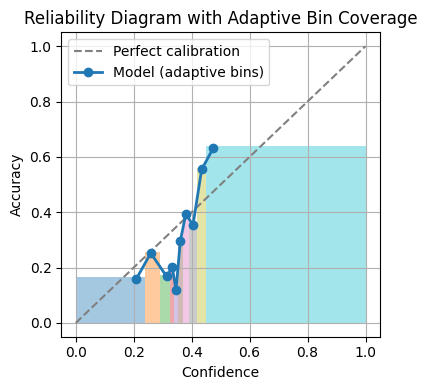

 25%|██▌       | 5/20 [00:28<01:12,  4.83s/it]

Current ECE: 0.09767452627420425


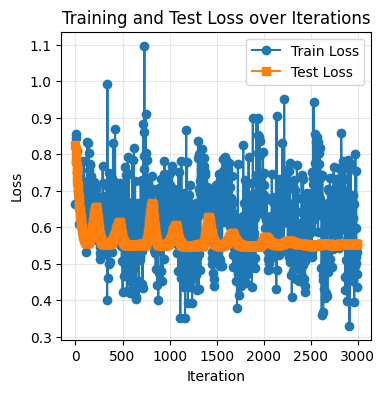

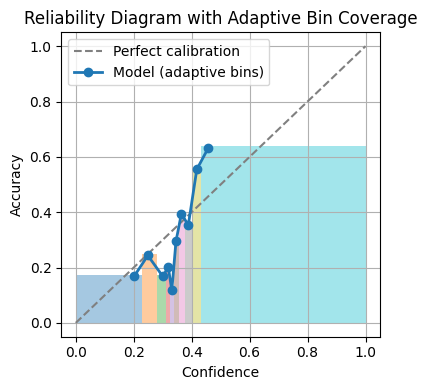

 30%|███       | 6/20 [00:33<01:09,  4.94s/it]

Current ECE: 0.09376005828380585


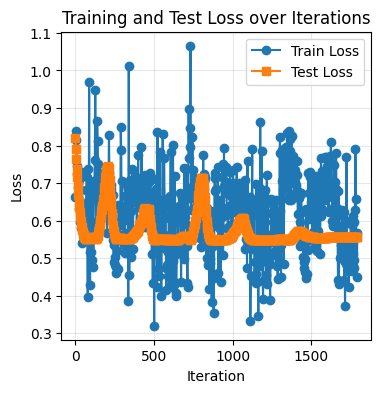

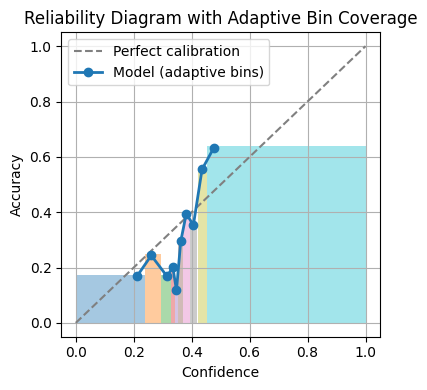

 35%|███▌      | 7/20 [00:35<00:52,  4.00s/it]

Current ECE: 0.09838994592428207


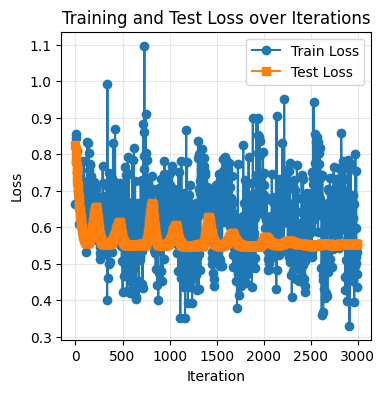

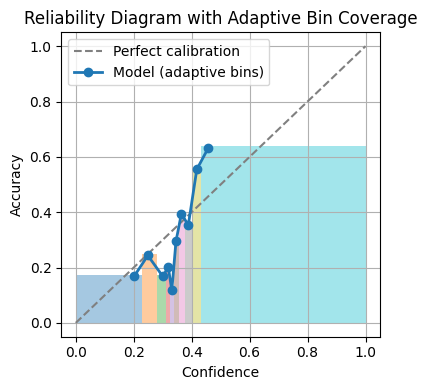

 40%|████      | 8/20 [00:38<00:45,  3.77s/it]

Current ECE: 0.09376005828380585


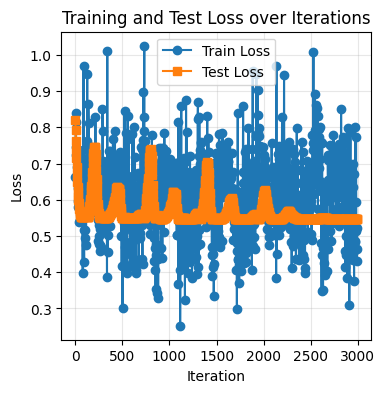

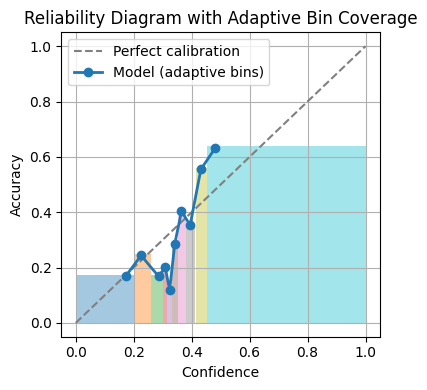

 45%|████▌     | 9/20 [00:43<00:44,  4.02s/it]

Current ECE: 0.086819589138031


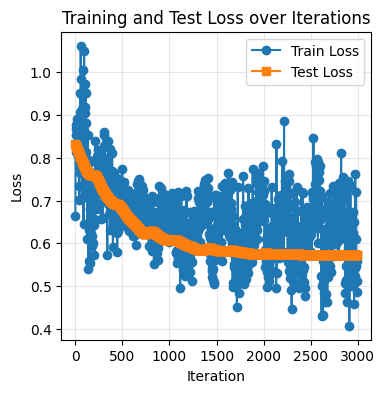

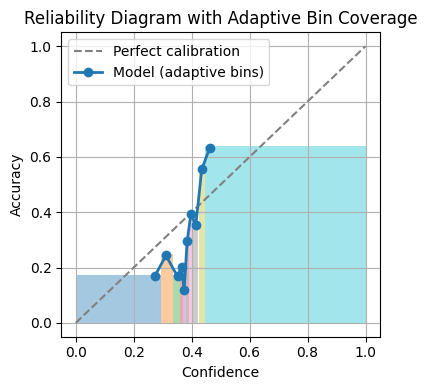

 50%|█████     | 10/20 [00:48<00:43,  4.30s/it]

Current ECE: 0.12229548394680023


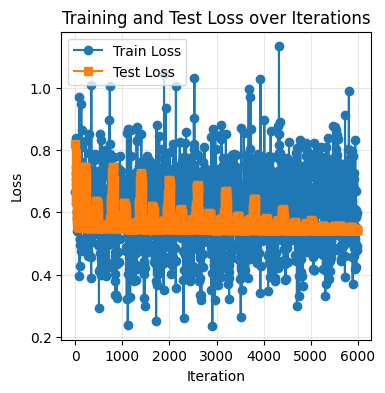

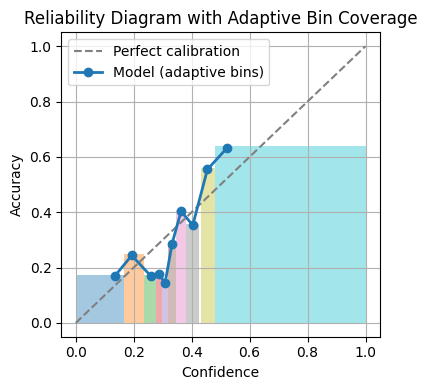

 55%|█████▌    | 11/20 [00:57<00:52,  5.88s/it]

Current ECE: 0.08042940497398376


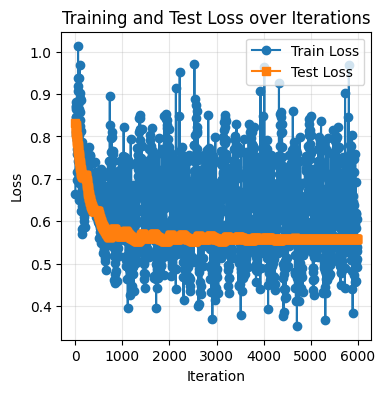

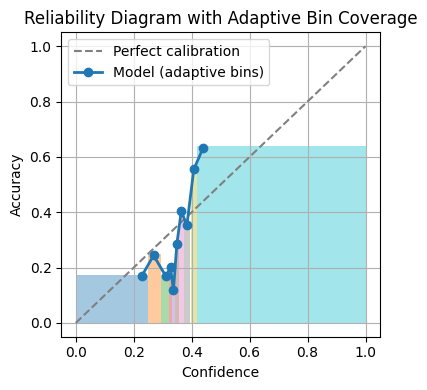

 60%|██████    | 12/20 [01:05<00:52,  6.53s/it]

Current ECE: 0.1051870584487915


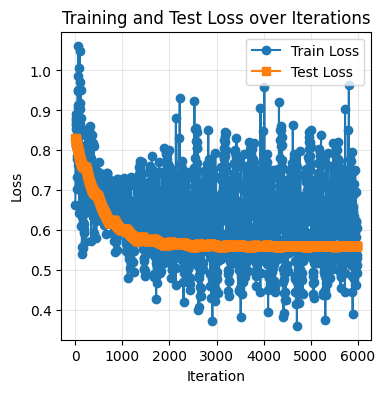

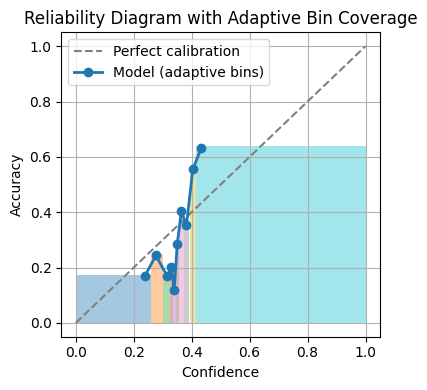

 65%|██████▌   | 13/20 [01:14<00:49,  7.13s/it]

Current ECE: 0.1090611070394516


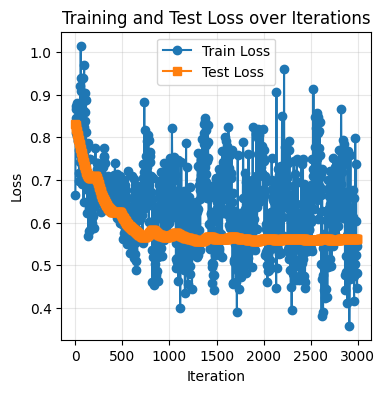

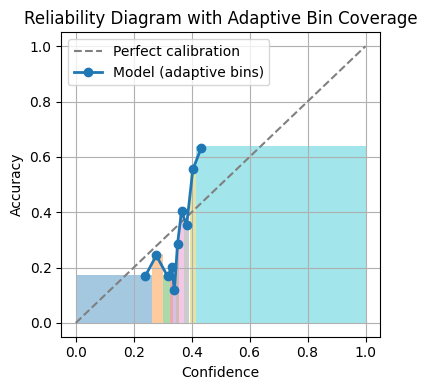

 70%|███████   | 14/20 [01:20<00:40,  6.77s/it]

Current ECE: 0.10972613096237183


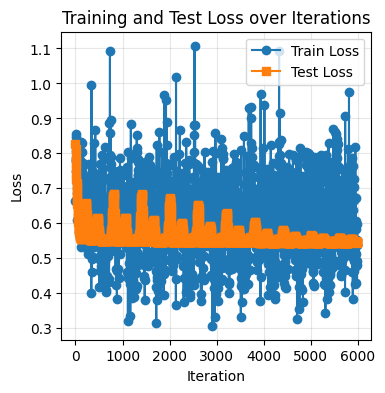

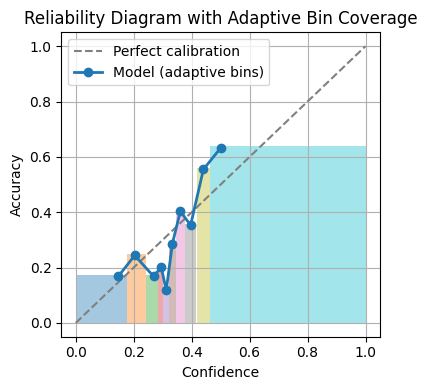

 75%|███████▌  | 15/20 [01:29<00:38,  7.65s/it]

Current ECE: 0.08337947726249695


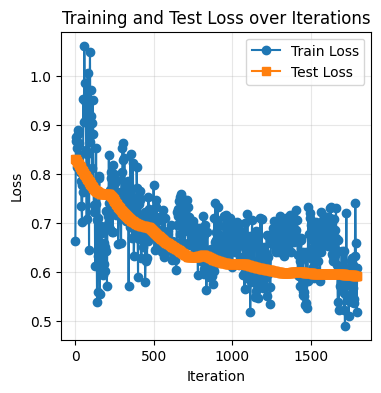

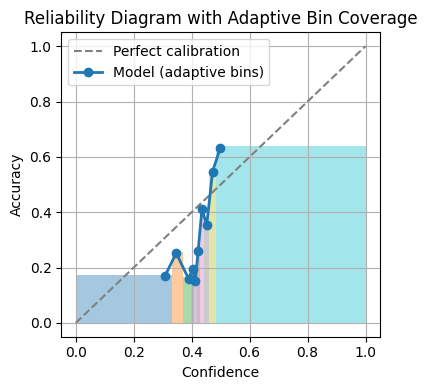

 80%|████████  | 16/20 [01:32<00:24,  6.11s/it]

Current ECE: 0.14267036318778992


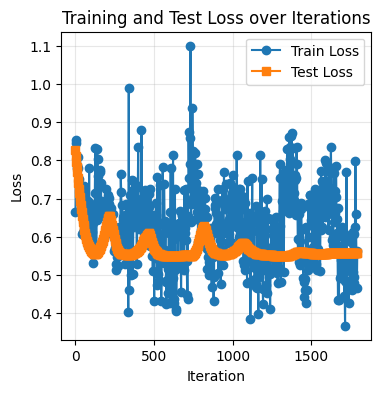

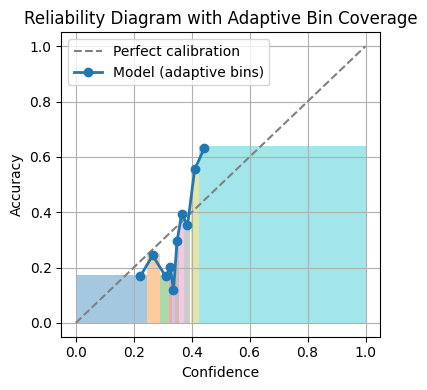

 85%|████████▌ | 17/20 [01:35<00:15,  5.15s/it]

Current ECE: 0.10195531696081161


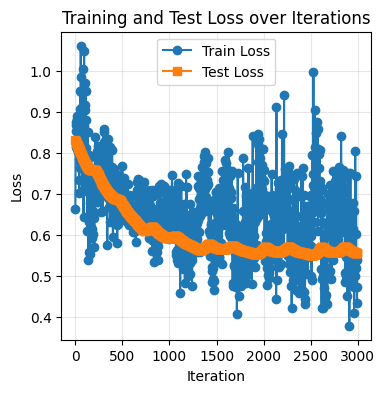

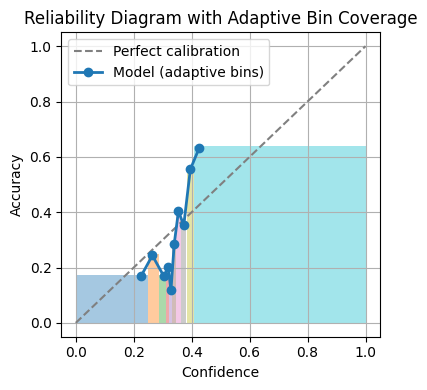

 90%|█████████ | 18/20 [01:39<00:09,  4.95s/it]

Current ECE: 0.10383036732673645


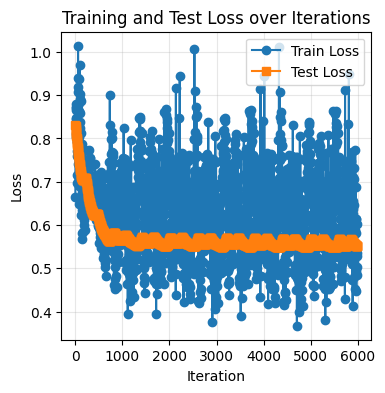

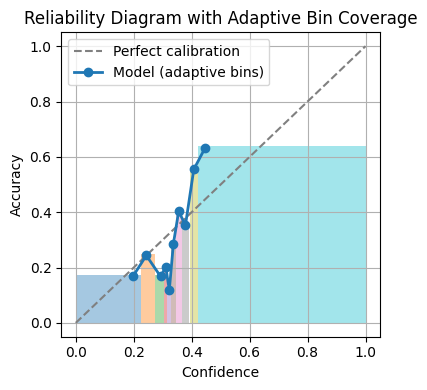

 95%|█████████▌| 19/20 [01:49<00:06,  6.32s/it]

Current ECE: 0.09334959834814072


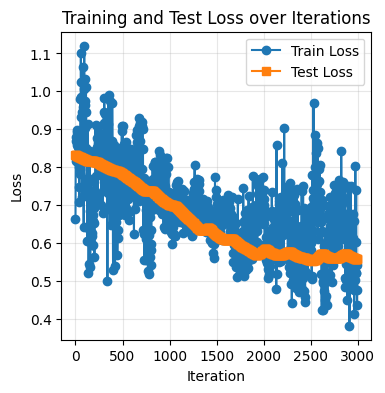

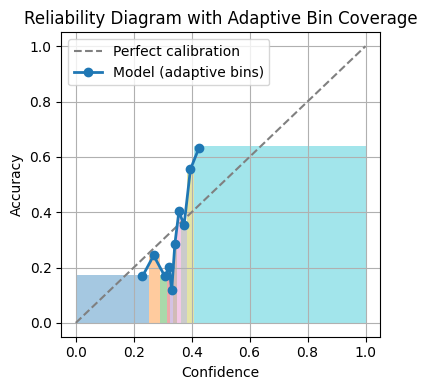

100%|██████████| 20/20 [01:53<00:00,  5.70s/it]

Current ECE: 0.10589058697223663


In [ ]:
fit_results = fit_hparameters(
    train=train,
    test=val,
    verbose=True
)

### Testing model

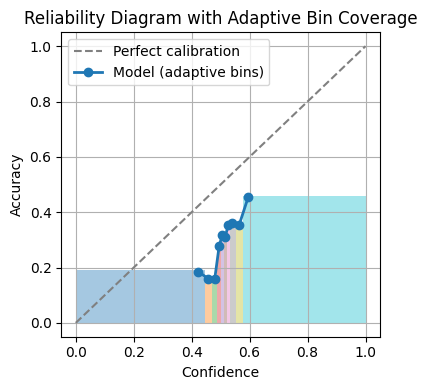

ECE on NON calibrated answer (test data): 0.21647769212722778


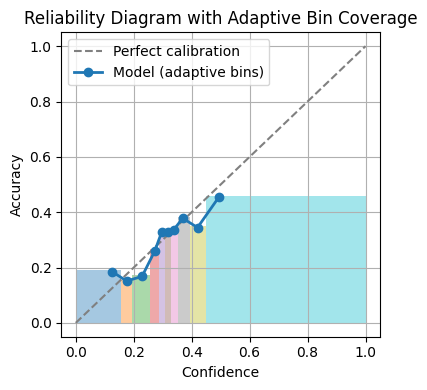

ECE on calibrated answer (test data): 0.03257094696164131
Accuracy on answer from test: 0.2944120168685913


In [ ]:
model = BetaCalibration()
model.load_state_dict(fit_results["parameters"])
model.eval()
    
test_data = test.get()
    
test_calibration_model(
    model,
    test_data["attn_confidence"], test_data["final_token_confidence"],
    test_data["labels"],
)

In [ ]:
[x for x in model.named_parameters()]

[('log_a',
  Parameter containing:
  tensor(1.3089, device='cuda:3', requires_grad=True)),
 ('log_b',
  Parameter containing:
  tensor(0.5664, device='cuda:3', requires_grad=True)),
 ('c',
  Parameter containing:
  tensor(-0.2283, device='cuda:3', requires_grad=True)),
 ('logit_gamma',
  Parameter containing:
  tensor(0.4620, device='cuda:3', requires_grad=True))]